# **4. Modelado Pyspark - Click-Through Rate**

## **Importación librerías**

Se importan las librerías necesarias para el modelado, se importan herramientas para división de datos y  preprocesamiento.

In [1]:
import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import platform
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_timestamp, col, when, hour
import pyspark
from pyspark.sql.functions import countDistinct
from pyspark.sql.types import IntegerType, DoubleType, StringType
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import time
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml import Pipeline
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql import functions as F
import sys



## **Creación de la Sesión Spark y Carga del Dataset** 

Se inicia una sesión de Apache Spark configurada para ejecución local con 8 GB de memoria asignada, optimizando así el manejo de recursos para el procesamiento distribuido. 

In [2]:
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [3]:
print("Driver usando Python:", platform.python_version())
print("PYSPARK_PYTHON:", os.environ["PYSPARK_PYTHON"])

Driver usando Python: 3.9.23
PYSPARK_PYTHON: c:\Users\CRISTIAN\miniconda3\envs\ml_venv\python.exe


In [4]:
spark = SparkSession.builder \
    .appName("WSL Spark Demo") \
    .master("local[*]") \
    .config("spark.driver.memory", "10g") \
    .config("spark.executor.memory", "10g") \
    .getOrCreate()

In [5]:
df_spark = spark.read.csv(os.path.join(os.getcwd(), r'datos\train\train.csv'), header=True, inferSchema=True)

### **Encabezado Dataframe**

In [6]:
df_spark.show(5)

+--------------------+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|                  id|click|    hour|  C1|banner_pos| site_id|site_domain|site_category|  app_id|app_domain|app_category|device_id|device_ip|device_model|device_type|device_conn_type|  C14|C15|C16| C17|C18|C19|   C20|C21|
+--------------------+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
| 1000009418151094273|    0|14102100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    07d7df22| a99f214a| ddd2926e|    44956a24|          1|               2|15706|320| 50|1722|  0| 35|    -1| 79|
|10000169349117863715|    0|14102100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    

### **Tamaño Dataset**

In [7]:
df_spark.count()

40428967

El dataset completo cuenta con 40 millones de observaciones. Para este experimento se aplica **undersampling** reduciendo el volumen a **10 millones de registros** con un balance perfecto de clases (**50% clase 0 / 50% clase 1**), lo que permite al MLP aprender patrones de ambas clases sin sesgo hacia la mayoritaria y reduce significativamente el tiempo de entrenamiento respecto al dataset completo.


### **Extracción y conversión de variables temporales**

Posteriormente, extraemos variables temporales específicas con el fin de analizar los datos con mayor detalle, para esto, creamos una nueva variable que corresponde a `hour`.  

In [8]:
df_spark = df_spark.withColumn(
    "datetime",
    to_timestamp(col("hour").cast("string"), "yyMMddHH")
)

In [9]:
df_spark = df_spark.withColumn(
    "hour",
    hour("datetime")
)

### **Elimininamos variables identificadoras**

In [10]:
df_spark = df_spark.drop('id','device_id','device_ip','app_id','site_id', 'datetime', 'C14')

In [11]:
df_spark.show(5)

+-----+----+----+----------+-----------+-------------+----------+------------+------------+-----------+----------------+---+---+----+---+---+------+---+
|click|hour|  C1|banner_pos|site_domain|site_category|app_domain|app_category|device_model|device_type|device_conn_type|C15|C16| C17|C18|C19|   C20|C21|
+-----+----+----+----------+-----------+-------------+----------+------------+------------+-----------+----------------+---+---+----+---+---+------+---+
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    44956a24|          1|               2|320| 50|1722|  0| 35|    -1| 79|
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    711ee120|          1|               0|320| 50|1722|  0| 35|100084| 79|
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    8a4875bd|          1|               0|320| 50|1722|  0| 35|100084| 79|
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    

### **Separación tipo de variables**

In [12]:
var_anon = ['C1','C15','C16','C17','C18','C19','C20','C21']
var_cat = ['banner_pos','site_domain','site_category','app_domain','app_category','device_type','device_model','device_conn_type','hour']

In [13]:
df_spark.printSchema()

root
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)



### **Conversión a variables categóricas**

Se convierten las variables anónimas y categóricas al tipo `StringType()` dentro del DataFrame de PySpark. Esto asegura que sean tratadas correctamente como variables categóricas en las etapas posteriores de transformación y modelado.



In [14]:
for var in var_anon+var_cat:  
    df_spark = df_spark.withColumn(var, col(var).astype(StringType()))


In [15]:
df_spark.printSchema()

root
 |-- click: integer (nullable = true)
 |-- hour: string (nullable = true)
 |-- C1: string (nullable = true)
 |-- banner_pos: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- device_conn_type: string (nullable = true)
 |-- C15: string (nullable = true)
 |-- C16: string (nullable = true)
 |-- C17: string (nullable = true)
 |-- C18: string (nullable = true)
 |-- C19: string (nullable = true)
 |-- C20: string (nullable = true)
 |-- C21: string (nullable = true)



### **Reducción de cardinalidad - Top 50 categorías**


Para las variables con de alta cardinalidad, se conservan únicamente las **50 categorías más frecuentes** y el resto se agrupa bajo la etiqueta `'OTHER'`. Esto lo realizamos con el objetivo de evitar una explosión de dimensionalidad a la hora de implementar `OneHotEncoding`.


In [16]:
TOP_N = 50 
vars_categoricas = var_cat + var_anon

for var in vars_categoricas:
    freq = df_spark.groupBy(var).count().orderBy(F.desc('count'))
    top_list = [row[var] for row in freq.limit(TOP_N).collect()]

    df_spark = df_spark.withColumn(
        var,
        when(col(var).isin(top_list), col(var)).otherwise('OTHER')
    )


## **Undersampling y Separación conjunto Train - Test**

Se aplica **undersampling** para reducir el dataset de 40M a 10M de registros balanceados (50% click / 50% no click). La clase minoritaria (click=1) se toma completa y se muestrea la clase mayoritaria (click=0) hasta igualar su tamaño. Posteriormente se divide en 80% train y 20% test manteniendo el balance de clases.

In [17]:
df_spark = df_spark.cache()

TARGET_TOTAL = 10_000_000  
TARGET_PER_CLASS = TARGET_TOTAL // 2 

df_minority = df_spark.filter(col('click') == 1) 
df_majority = df_spark.filter(col('click') == 0)  

n_minority = df_minority.count()
n_majority = df_majority.count()
print(f'Clase 1 original: {n_minority:,} | Clase 0 original: {n_majority:,}')

n_take = min(n_minority, TARGET_PER_CLASS)
fraction_maj = n_take / n_majority
fraction_min = n_take / n_minority

df_minority_s = df_minority.sample(withReplacement=False, fraction=fraction_min, seed=42)
df_majority_s = df_majority.sample(withReplacement=False, fraction=fraction_maj, seed=42)

df_balanced = df_minority_s.union(df_majority_s).orderBy(F.rand(seed=42))
print(f'Dataset balanceado: {df_balanced.count():,} registros')

train_data, test_data = df_balanced.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train_data.count():,} | Test: {test_data.count():,}')


Clase 1 original: 6,865,066 | Clase 0 original: 33,563,901
Dataset balanceado: 10,000,217 registros
Train: 8,000,396 | Test: 1,999,747


## **Validación de la distribución de clases**

Se verifica que la división entre Train y Test mentangan la proporción original de la variable objetivo `click`.

In [18]:
print("Distribución en train:")
train_dist = train_data.groupBy("click").count().toPandas()
print(train_dist)

print("\nDistribución en test:")
test_dist = test_data.groupBy("click").count().toPandas()  
print(test_dist)

Distribución en train:
   click    count
0      1  3998595
1      0  4001721

Distribución en test:
   click   count
0      1  999900
1      0  999895


Ambos conjuntos conservan la distribución balanceada **50% click / 50% no click** producto del undersampling, lo que garantiza que el MLP reciba señal equitativa de ambas clases durante el entrenamiento.


## **Preprocesamiento variables**

In [19]:
vars_categoricas = var_cat + var_anon

indexers = [
    StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
    for c in vars_categoricas
]

encoders = [
    OneHotEncoder(inputCol=f'{c}_idx', outputCol=f'{c}_ohe', dropLast=True, handleInvalid='keep')
    for c in vars_categoricas
]

ohe_cols = [f'{c}_ohe' for c in vars_categoricas]

final_assembler = VectorAssembler(
    inputCols=ohe_cols,
    outputCol='features'
)


Se utiliza **One Hot Encoding** en lugar de `StringIndexer` directo, dado que OneHot representa correctamente la naturaleza nominal de las variables categóricas sin imponer un orden numérico artificial entre categorías.

Gracias al top-50 aplicado previamente, la dimensionalidad es controlada, cada variable aporta máximo 50 columnas binarias, lo que hace viable el preprocesamiento a esta escala.


## **Pipeline**

In [20]:
prep_pipeline = Pipeline(stages=indexers + encoders + [final_assembler])
prep_model    = prep_pipeline.fit(train_data)

sample       = prep_model.transform(train_data.limit(1))
num_features = len(sample.select('features').first()[0])
print(f'Número de features tras OHE: {num_features}')


Número de features tras OHE: 496


El pipeline se entrena por medio de `fit` sobre el conjunto de entrenamiento y se aplica una transformación de prueba sobre una muestra para verificar el resultado. Se extrae el número de features generado, que corresponde a la cantidad total de columnas indexadas ingresadas al ensamblador. 

## **Configuración de hiperparámetros (Grid Search)**

Se define una grilla de hiperparámetros para la red neuronal en PySpark. El grid search explorará todas las combinaciones de las siguientes opciones:

* `layers`: Define la arquitectura de la red (entrada → capa oculta → salida).

    * `[num_features, 10, 2]`: capa oculta con **10** neuronas.

    * `[num_features, 50, 2]`: capa oculta con **50** neuronas.

    * `[num_features, 100, 2]`: capa oculta con **100** neuronas.

* `stepSize`: Tasa de aprendizaje — se evalua el valor de **0.01**.

* `maxIter`: Número máximo de iteraciones fijado en **100**.

Esto produce un total de **3 combinaciones**.

In [21]:
configs = [
    {'layers': [num_features, 10,  2], 'stepSize': 0.01, 'maxIter': 100},
    {'layers': [num_features, 50,  2], 'stepSize': 0.01, 'maxIter': 100},
    {'layers': [num_features, 100, 2], 'stepSize': 0.01, 'maxIter': 100},
]

print(f'Grid search: {len(configs)} combinaciones de hiperparámetros')
for c in configs:
    print(f"  layers={c['layers']}, stepSize={c['stepSize']}, maxIter={c['maxIter']}")


Grid search: 3 combinaciones de hiperparámetros
  layers=[496, 10, 2], stepSize=0.01, maxIter=100
  layers=[496, 50, 2], stepSize=0.01, maxIter=100
  layers=[496, 100, 2], stepSize=0.01, maxIter=100


## **Entrenamiento y métricas de evaluación**

In [ ]:
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol='click',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol='click', predictionCol='prediction', metricName='precisionByLabel')
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol='click', predictionCol='prediction', metricName='recallByLabel')
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='click', predictionCol='prediction', metricName='fMeasureByLabel')

results = []

train_transformed = prep_model.transform(train_data).cache()
test_transformed  = prep_model.transform(test_data).cache()

for config in configs:
    print(f'\nEntrenando: {config}')

    mlp = MultilayerPerceptronClassifier(
        layers=config['layers'],
        stepSize=config['stepSize'],
        maxIter=config['maxIter'],
        solver='l-bfgs',
        labelCol='click',
        featuresCol='features',
        seed=42
    )

    start_train = time.time()
    mlp_model   = mlp.fit(train_transformed)
    train_time  = time.time() - start_train

    start_pred  = time.time()
    predictions = mlp_model.transform(test_transformed)
    pred_time   = time.time() - start_pred

    auc       = evaluator_auc.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions, {evaluator_precision.metricLabel: 1.0})
    recall    = evaluator_recall.evaluate(predictions, {evaluator_recall.metricLabel: 1.0})
    f1        = evaluator_f1.evaluate(predictions, {evaluator_f1.metricLabel: 1.0})

    results.append({
        'layers'    : str(config['layers']),
        'stepSize'  : config['stepSize'],
        'maxIter'   : config['maxIter'],
        'auc'       : auc,
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'train_time': train_time,
        'pred_time' : pred_time
    })

    print(f'AUC: {auc:.4f} | P: {precision:.4f} | R: {recall:.4f} | F1: {f1:.4f} | '
          f'Train: {train_time:.1f}s | Pred: {pred_time:.1f}s')

    predictions.groupBy('click', 'prediction').count().show()

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_idx = results_df['auc'].idxmax()
best = results_df.iloc[best_idx]
print(f'\n Mejor configuración (mayor AUC):')
print(f'   layers={best["layers"]}, stepSize={best["stepSize"]}, maxIter={best["maxIter"]}')
print(f'   AUC={best["auc"]:.4f} | Precision={best["precision"]:.4f} | Recall={best["recall"]:.4f} | F1={best["f1"]:.4f}')

best_config = configs[results_df['auc'].idxmax()]

best_mlp = MultilayerPerceptronClassifier(
    layers    = best_config['layers'],
    stepSize  = best_config['stepSize'],
    maxIter   = best_config['maxIter'],
    solver    = 'l-bfgs',
    labelCol  = 'click',
    featuresCol = 'features',
    seed      = 42
)
best_model       = best_mlp.fit(train_transformed)
best_predictions = best_model.transform(test_transformed)


Entrenando: {'layers': [496, 10, 2], 'stepSize': 0.01, 'maxIter': 100}
AUC: 0.7179 | P: 0.6489 | R: 0.7264 | F1: 0.6854 | Train: 1599.0s | Pred: 0.1s
+-----+----------+------+
|click|prediction| count|
+-----+----------+------+
|    1|       0.0|273747|
|    0|       0.0|607794|
|    1|       1.0|726644|
|    0|       1.0|393175|
+-----+----------+------+


Entrenando: {'layers': [496, 50, 2], 'stepSize': 0.01, 'maxIter': 100}
AUC: 0.7190 | P: 0.6439 | R: 0.7235 | F1: 0.6814 | Train: 5807.6s | Pred: 0.1s
+-----+----------+------+
|click|prediction| count|
+-----+----------+------+
|    1|       0.0|276651|
|    0|       0.0|600755|
|    1|       1.0|723740|
|    0|       1.0|400214|
+-----+----------+------+


Entrenando: {'layers': [496, 100, 2], 'stepSize': 0.01, 'maxIter': 100}
AUC: 0.7162 | P: 0.6407 | R: 0.7251 | F1: 0.6803 | Train: 7308.6s | Pred: 0.1s
+-----+----------+------+
|click|prediction| count|
+-----+----------+------+
|    1|       0.0|274964|
|    0|       0.0|594093

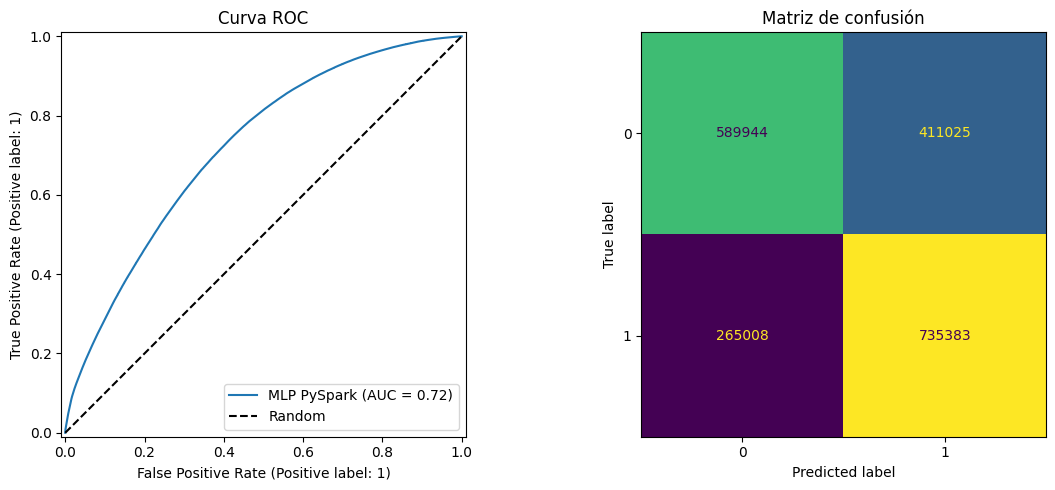

In [23]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

results_df = best_predictions.select(
    'click',
    'prediction',
    'probability'
).toPandas()

y_true = results_df['click'].values
y_pred_spark = results_df['prediction'].values
y_prob_spark = np.array(results_df['probability'].tolist())[:, 1] 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_true, y_prob_spark,
    ax=axes[0],
    name='MLP PySpark'
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('Curva ROC')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_spark,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('Matriz de confusión')

plt.tight_layout()
plt.show()

**Métricas de rendimiento**:

* `AUC`: 0.7190, indica una capacidad discriminativa moderada, superior a un clasificador aleatorio (0.5), pero con margen de mejora.

* `Precisión`: 0.6439, de cada 100 predicciones positivas, aproximadamente 64 son realmente clics.

* `Recall`: 0.7235, el modelo logra detectar cerca del 73% de los clics reales, mostrando una buena capacidad para identificar la clase positiva.

* `F1-score`: 0.6814,  refleja un balance aceptable entre precisión y recall, aunque aún puede optimizarse.

**Matriz de confusión:**

* `Verdaderos negativos`: 589,944

* `Falsos positivos`: 411,025

* `Falsos negativos`: 265,008

* `Verdaderos positivos`: 735,383

El modelo en PySpark presenta un rendimiento moderadamente bueno en la detección de clicks, superando al modelado en Scikit-learn en métricas como `Precisión`, `Recall`, `F1-score`, pero quedando atrás en `ROC-AUC`


## **Interpretabilidad con LIME**

In [24]:

feature_names = []

indexer_models  = [s for s in prep_model.stages if hasattr(s, 'labels')]      
encoder_models  = [s for s in prep_model.stages if hasattr(s, 'categorySizes')] 

for idx_model, enc_model in zip(indexer_models, encoder_models):
    col_name  = idx_model.getInputCol()          
    labels    = idx_model.labels                 
    n_cats    = enc_model.categorySizes[0] - 1   

    for i in range(n_cats):
        cat_label = labels[i] if i < len(labels) else 'OTHER'
        feature_names.append(f'{col_name}={cat_label}')

print(f"Features reconstruidos: {len(feature_names)}")
print(feature_names[:5]) 

Features reconstruidos: 479
['banner_pos=0', 'banner_pos=1', 'banner_pos=7', 'banner_pos=2', 'banner_pos=4']


Índice: 1 | Real: 0 | Predicho: 1.0
Vector: 496 | Names: 496


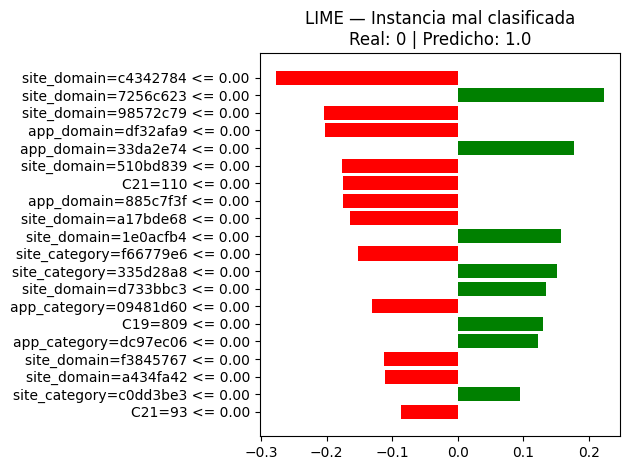

In [25]:
import lime
import lime.lime_tabular

N_SAMPLE = 2000 

test_sample = predictions.select('click', 'prediction', 'features') \
                         .limit(N_SAMPLE) \
                         .toPandas()

features_array = np.array(test_sample['features'].tolist())
y_pred_array   = test_sample['prediction'].values
y_test_array   = test_sample['click'].values

train_sample = prep_model.transform(train_data) \
                         .select('features') \
                         .limit(N_SAMPLE) \
                         .toPandas()
X_train_array = np.array(train_sample['features'].tolist())

def predict_fn(data):
    from pyspark.ml.linalg import Vectors
    rows = [{'features': Vectors.dense(row)} for row in data]
    spark_df = spark.createDataFrame(rows)
    preds = mlp_model.transform(spark_df).select('probability').toPandas()
    return np.array(preds['probability'].tolist())

mal_clasificados = np.where(y_pred_array != y_test_array)[0]
idx = mal_clasificados[0]
print(f"Índice: {idx} | Real: {y_test_array[idx]} | Predicho: {y_pred_array[idx]}")

feature_names = []

for idx_model, enc_model in zip(indexer_models, encoder_models):
    col_name = idx_model.getInputCol()
    labels   = idx_model.labels
    n_cats   = enc_model.categorySizes[0] - 1

    for i in range(n_cats):
        cat_label = labels[i] if i < len(labels) else f'cat_{i}'
        feature_names.append(f'{col_name}={cat_label}')

n_vector = features_array.shape[1]
while len(feature_names) < n_vector:
    feature_names.append(f'feature_{len(feature_names)}')

print(f"Vector: {n_vector} | Names: {len(feature_names)}")

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=feature_names,
    class_names=['no click', 'click'],
    mode='classification',
    random_state=42
)

exp = explainer.explain_instance(
    data_row=features_array[idx],
    predict_fn=predict_fn,
    num_features=20
)

fig = exp.as_pyplot_figure()
plt.title(f"LIME — Instancia mal clasificada\nReal: {y_test_array[idx]} | Predicho: {y_pred_array[idx]}")
plt.tight_layout()
plt.show()

### **Interpretación**

Para la interpretación con LIME, graficamos el top de 20 variables más influyentes en la predicción del modelo.

Las variables de dominio `site_domain` y `app_domain`, son las más determinantes, concentrando los mayores impactos tanto positivos como negativos, lo que sugiere que el origen del tráfico es un factor determinante a la hora de predecir clicks.

La variable `site_category` muestra efectos tanto positivos como negativos en la predicción de clicks, esto revela que la probabilidad de click presenta diferencias con relación a la temática del sitio web.

Las variables anónimas `C20`, `C21` aparecen con impactos menores, esto implica que su contribución al modelo es más limitada o se manifiesta a través de interacciones más complejas.

El modelo logra identificar patrones específicos donde ciertos dominios de paginas web como `7256c623`, presentan alta tasa de clicks, mientras que otros dominios como `c4342784`, `98572c79`, `510bd839` están asociados usualmente a flata de clicks, esta información resulta valiosa para la optimización de campañas centradas estos sitios. Por otro lado, dominios específicos de ciertas aplicaciones como `df32afa9`, `885c7f3f`, aumentan la probabilidad de no click. El único dominio de aplicación asociado a mayor número de clicks es `33da2e74`.



# **Conclusiones**


### **Tabla comparativa**

| Métrica                      | Scikit-learn                     | PySpark                     |
|------------------------------|----------------------------------|-----------------------------------------------|
| AUC                          | 0.7250                           | 0.7190                                     |
| Precisión                    | 0.60                             | 0.64                                         |
| Recall                       | 0.06                             | 0.72                                     |
| F1-score                     | 0.10                             | 0.68                                     |
| Método de encoding           | Target Encoding (con suavizado)  | StringIndexer + OneHotEncoder + VectorAssembler |
| Tratamiento categorías raras | Agrupación en OTHER (umbral 5000)| Top 50 categorías más frecuentes              |
| Tamaño de datos              | 1M registros (subsample 80-20)         | 10M registros (undersampling 50-50)           |
| Tiempo de entrenamiento      | 1,801.6s (30 min)                | 5,807.6s (1 hora 36 minutos)                 |


**Análisis de resultados:**

* **Scikit-learn** logró un rendimiento moderado en la detección de clics (recall 6%, precisión 60%), con un AUC aceptable de 0.725, gracias al uso de `Target Encoding` y la posibilidad de ajustar finamente hiperparámetros y estrategias de regularización. Sin embargo, el bajo recall indica dificultades para capturar la clase minoritaria.

* **PySpark**, con una estrategia de undersampling (50-50) y un dataset de 10M registros, logró un rendimiento notablemente superior en la detección de clicks, con un recall de 72% y precisión de 64%, alcanzando un F1-score de 0.68 y un AUC de 0.7190, muy cercano al obtenido con Scikit-learn. Esto demuestra que el manejo del desbalance de clases fue clave para mejorar la capacidad predictiva sobre la clase minoritaria.

**Ventajas y limitaciones de cada enfoque:**

Scikit-learn ofrece una mayor flexibilidad y variedad de técnicas para el preprocesamiento de variables, entre las cuales encontramos `Target Encoding`, `One Hot Encoding`, `Label Encoding` y `Ordinal Encoder`, así como una amplia gama de hiperparámetros en los modelos integrados. Sin embargo, no escala a volúmenes de 40M registros de manera eficiente y su rendimiento se ve limitado sin un tratamiento adecuado del desbalance de clases.

PySpark destaca en la lectura, visualización y manipulación de datasets masivos, así como en la capacidad de aplicar técnicas de muestreo como undersampling a gran escala. No obstante, sus opciones de encoding son más limitadas. Además, los modelos disponibles tienen menos parámetros ajustables en comparación con Scikit-learn, lo que puede dificultar replicar estrategias avanzadas como `Target Encoding`.

Como conclusión, para proyectos con datasets masivos y clases desbalanceadas, lo más recomendable es combinar lo mejor de ambos entornos, PySpark es ideal para el procesamiento y análisis de grandes volúmenes de datos, mientras que el modelado en Scikit-learn permite aprovechar su riqueza de técnicas de encoding, optimización y tuning de parámetros.
